# Setting

In [1]:
import os
import pandas as pd
import time
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [3]:
def load_data(path):
    df = pd.read_csv(path)
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]
    return X, y

def run_svm(train_path, test_path):
    X_train, y_train = load_data(train_path)
    X_test, y_test = load_data(test_path)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = SVC(kernel='rbf', C=1.0, gamma='scale', class_weight='balanced')
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print("Classification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix Heatmap')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

    print("Accuracy:", accuracy_score(y_test, y_pred))

def evaluate_svm_model(file_pairs, base_path):
    for train_file, test_file in file_pairs:
        print(f"\n----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ {train_file[:-4]} - {test_file[:-4]} -----")
        train_path = f"{base_path}\\{train_file}"
        test_path = f"{base_path}\\{test_file}"


        start_time = time.time()
        run_svm(train_path, test_path)
        end_time = time.time()

        print(f"Thời gian chạy bộ {train_file[:-4]}: {end_time - start_time:.2f} giây")


# Test

## Original


----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train41 - test41 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     14668
           1       0.95      0.94      0.95     11230

    accuracy                           0.95     25898
   macro avg       0.95      0.95      0.95     25898
weighted avg       0.95      0.95      0.95     25898



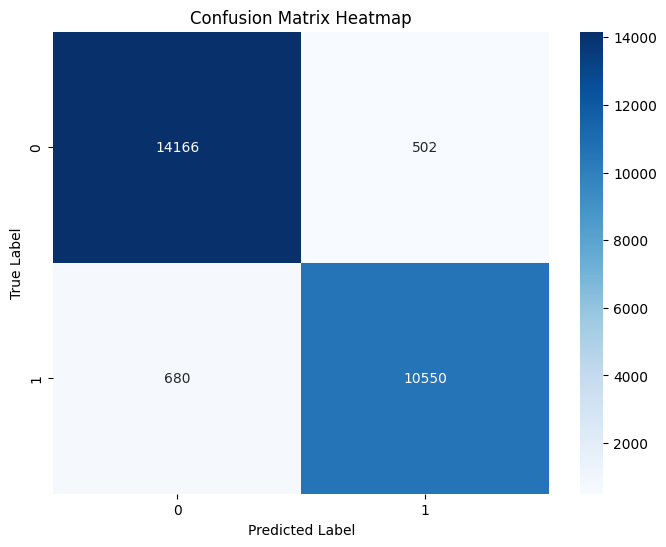

Accuracy: 0.9543594099930497
Thời gian chạy bộ train41: 214.41 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train64 - test64 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     29354
           1       0.95      0.94      0.95     22441

    accuracy                           0.95     51795
   macro avg       0.95      0.95      0.95     51795
weighted avg       0.95      0.95      0.95     51795



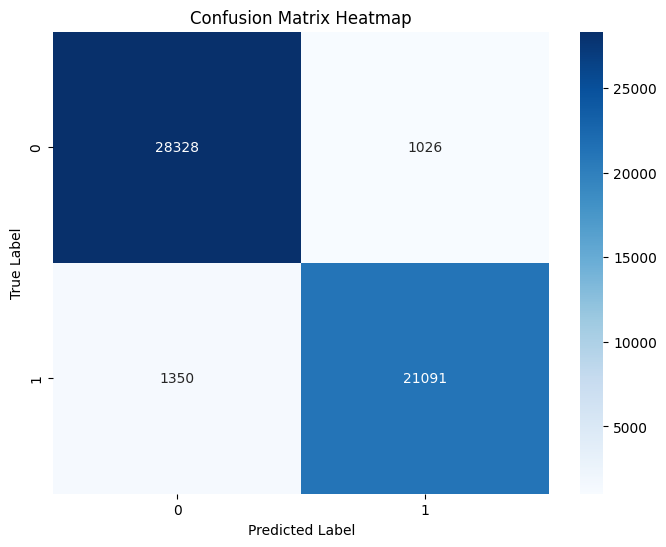

Accuracy: 0.9541268462206777
Thời gian chạy bộ train64: 141.09 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train73 - test73 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96     22029
           1       0.95      0.94      0.95     16818

    accuracy                           0.95     38847
   macro avg       0.95      0.95      0.95     38847
weighted avg       0.95      0.95      0.95     38847



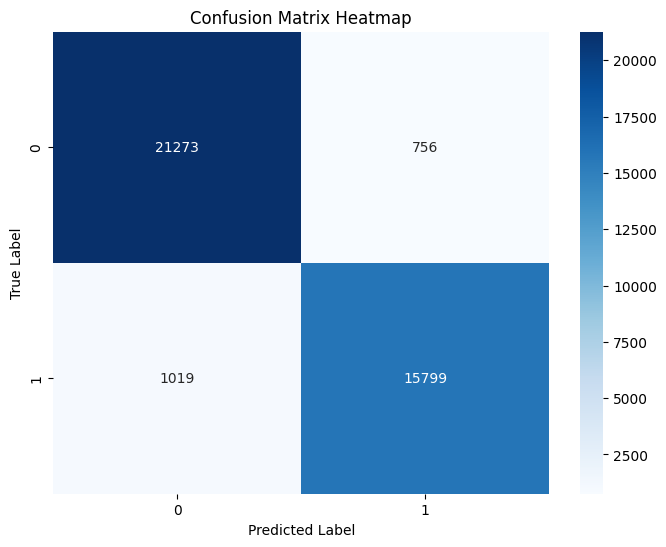

Accuracy: 0.954307925965969
Thời gian chạy bộ train73: 154.50 giây


In [5]:
file_pairs = [
    ("train41.csv", "test41.csv"),
    ("train64.csv", "test64.csv"),
    ("train73.csv", "test73.csv")
]
base_path = "..\data\original_data"

evaluate_svm_model(file_pairs, base_path)


## PCA


----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_pca_41 - test_pca_41 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88     14668
           1       0.85      0.81      0.83     11230

    accuracy                           0.86     25898
   macro avg       0.86      0.85      0.85     25898
weighted avg       0.86      0.86      0.86     25898



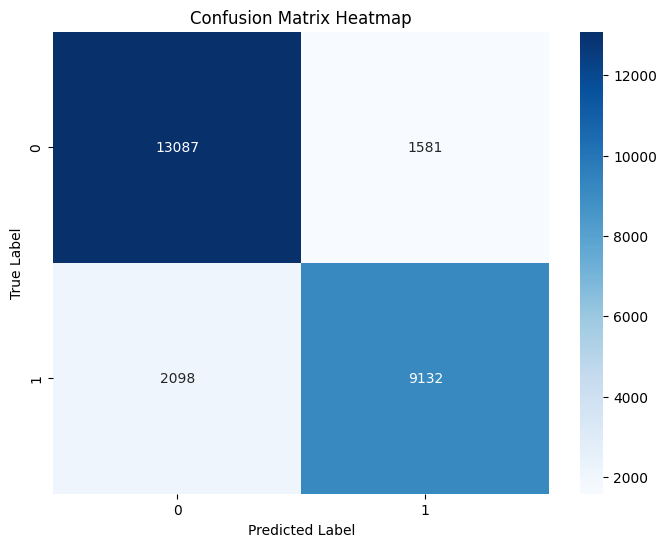

Accuracy: 0.8579426982778593
Thời gian chạy bộ train_pca_41: 168.06 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_pca_64 - test_pca_64 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.88     29354
           1       0.85      0.81      0.83     22441

    accuracy                           0.86     51795
   macro avg       0.86      0.85      0.85     51795
weighted avg       0.86      0.86      0.86     51795



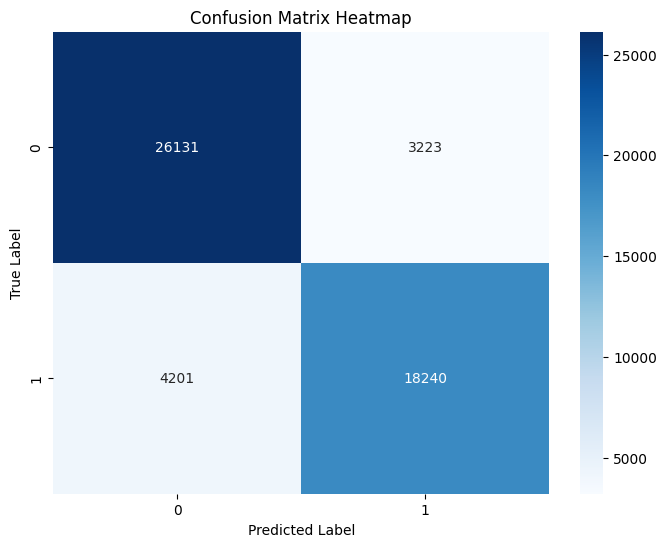

Accuracy: 0.8566657013225215
Thời gian chạy bộ train_pca_64: 94.44 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_pca_73 - test_pca_73 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86     22029
           1       0.83      0.79      0.81     16818

    accuracy                           0.84     38847
   macro avg       0.84      0.83      0.83     38847
weighted avg       0.84      0.84      0.84     38847



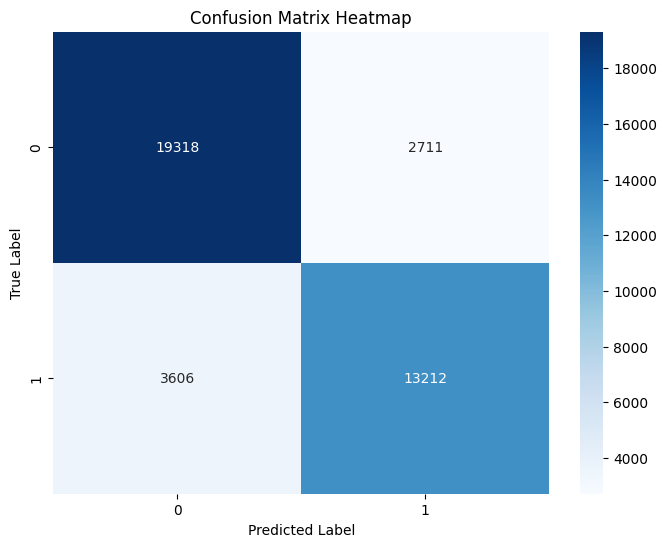

Accuracy: 0.8373877004659305
Thời gian chạy bộ train_pca_73: 122.90 giây


In [3]:
file_pairs = [
    ("train_pca_41.csv", "test_pca_41.csv"),
    ("train_pca_64.csv", "test_pca_64.csv"),
    ("train_pca_73.csv", "test_pca_73.csv")
]
base_path = "..\data\PCA_data"

evaluate_svm_model(file_pairs, base_path)


## LDA


----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_lda_41 - test_lda_41 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89     14668
           1       0.89      0.81      0.85     11230

    accuracy                           0.87     25898
   macro avg       0.88      0.87      0.87     25898
weighted avg       0.87      0.87      0.87     25898



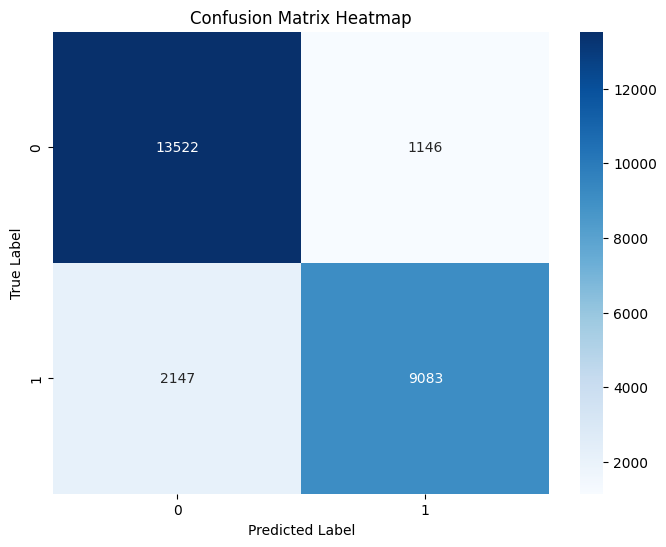

Accuracy: 0.8728473241176925
Thời gian chạy bộ train_lda_41: 232.95 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_lda_64 - test_lda_64 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89     29354
           1       0.88      0.80      0.84     22441

    accuracy                           0.87     51795
   macro avg       0.87      0.86      0.87     51795
weighted avg       0.87      0.87      0.87     51795



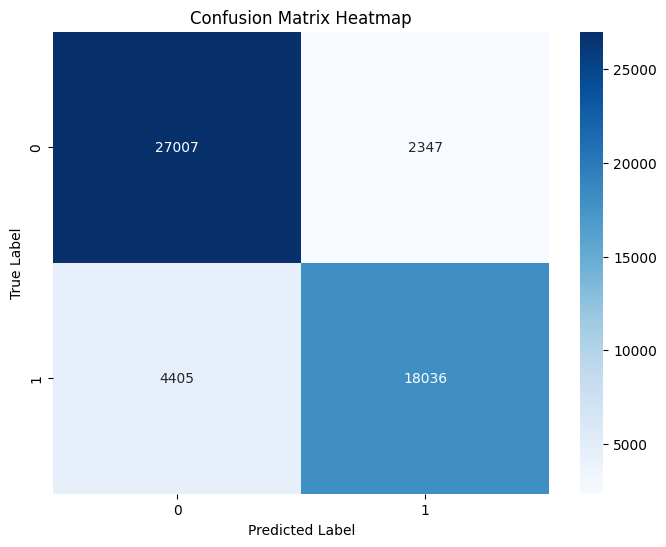

Accuracy: 0.8696399266338449
Thời gian chạy bộ train_lda_64: 145.92 giây

----- ĐÁNH GIÁ MÔ HÌNH SVM VỚI BỘ train_lda_73 - test_lda_73 -----
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.92      0.89     22029
           1       0.89      0.80      0.84     16818

    accuracy                           0.87     38847
   macro avg       0.87      0.86      0.87     38847
weighted avg       0.87      0.87      0.87     38847



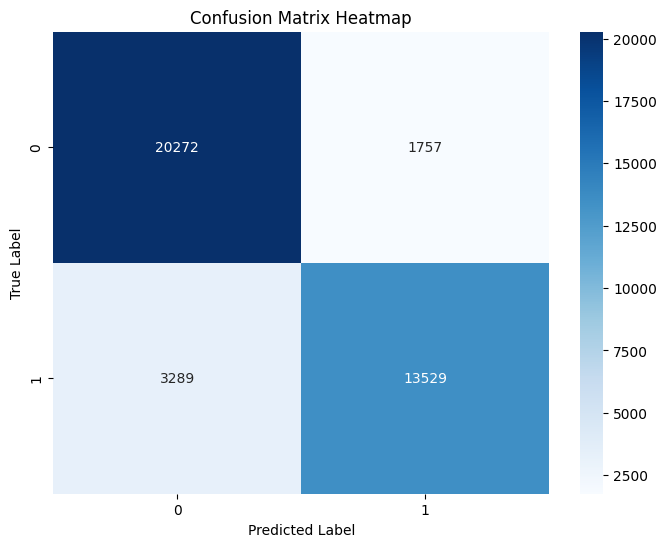

Accuracy: 0.8701057996756506
Thời gian chạy bộ train_lda_73: 217.97 giây


In [4]:
file_pairs = [
    ("train_lda_41.csv", "test_lda_41.csv"),
    ("train_lda_64.csv", "test_lda_64.csv"),
    ("train_lda_73.csv", "test_lda_73.csv")
]
base_path = "..\data\LDA_data"

evaluate_svm_model(file_pairs, base_path)